# 10-Cloud FinOps & Spot Instance Physics

In the previous nine lessons, we architected the ultimate Enterprise Data Platform. We built Event-Driven S3 topologies, highly available VPCs, serverless Fargate grids, Ephemeral SageMaker pipelines, and High-Throughput Bedrock LLM gateways.

However, a mathematically perfect architecture is a failure if it bankrupts the company. **Cloud FinOps (Financial Operations)** is the engineering discipline of treating cost as a physical hardware constraint.

The greatest weapon in a Cloud Data Engineer's FinOps arsenal is the **Amazon EC2 Spot Market**. AWS operates massive data centers globally. At any given microsecond, 30% to 40% of their physical servers are sitting idle. To monetize this unused hardware, AWS auctions it off at up to a **90% discount**.

But there is a catch—a strict rule of physics: **The Two-Minute Warning**. If an enterprise customer arrives and pays full price (On-Demand) for a server you are currently renting on the Spot Market, AWS will instantly reclaim your server. You have exactly 120 seconds to halt your compute, save your data, and shut down before the hypervisor violently executes a `SIGKILL`.

Let's boot our environment to engineer fault-tolerant, checkpoint-driven Spot architectures for $0.00.

In [1]:
# Required installations: pip install boto3 matplotlib seaborn numpy
import boto3
import json
import time
import numpy as np
from botocore.exceptions import ClientError
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & FinOps Spot Engine Initialized.")

✅ Systems Architecture & FinOps Spot Engine Initialized.


# 1. The Mathematics of Market Dynamics & Fault Tolerance

### The Spot Pricing Matrix

Let $C_{od}$ be the static hourly price of an On-Demand server (e.g., $1.00/hour).
Let $C_{spot}(t)$ be the dynamic Spot price at time $t$.
AWS guarantees that $C_{spot}(t)$ will never exceed $C_{od}$, but it constantly fluctuates based on regional supply and demand $\mathcal{D}$:


$$C_{spot}(t) = f(\mathcal{D}_{region}, \text{Idle Capacity})$$

### The Physics of Checkpointing (Idempotent Resumption)

Because the probability of termination $P_{kill}$ is $> 0$, any algorithm running on a Spot instance must be strictly **Stateless** or **Idempotent**.

If you are training a Deep Neural Network that takes 10 hours, and the Spot instance is killed at Hour 9, you lose 9 hours of compute. To survive, we implement **Checkpointing Frequency ($\Delta c$)**.
We continuously push the model's weight matrix $\mathbf{W}$ to Amazon S3 every $\Delta c$ minutes.

If a termination signal hits at $t_{kill}$, the compute dies. An Auto-Scaling Group instantly spins up a new Spot instance. The new instance downloads the latest checkpoint $\mathbf{W}_{c}$ from S3. The maximum possible compute time lost is strictly bounded by:


$$\text{Max Time Lost} = t_{kill} - t_{last\_checkpoint} \leq \Delta c$$

# 2. Imperative Execution: Boto3 Spot Fleet & Interruption Handlers (Local Simulation)

In a live EC2 environment, your Python script must continuously poll the localized EC2 Metadata Endpoint (`http://169.254.169.254/...`). If the response changes from HTTP 404 to HTTP 200, AWS has just initiated the 120-second countdown.

Because we are running locally ($0.00 cost), we will write the exact Boto3 code used to request a Spot Instance, and then we will mathematically simulate the interception of the Two-Minute Warning metadata payload.

In [2]:
# --- ⚙️ STEP 1: Initializing EC2 Control Plane (Local Vector) ---
print("--- 🚀 Initializing Boto3 Spot Fleet Provisioning (LocalStack) ---")
boto3.setup_default_session(aws_access_key_id='test', aws_secret_access_key='test', region_name='us-east-1')
local_endpoint = 'http://localhost:4566'

ec2_client = boto3.client('ec2', endpoint_url=local_endpoint)

# --- 📉 STEP 2: Dispatching the Spot Fleet Request ---
try:
    print(f"   [API CALL] Requesting Spot Market Compute Fleet...")
    spot_response = ec2_client.request_spot_instances(
        InstanceCount=1,
        Type='one-time',
        LaunchSpecification={
            'ImageId': 'ami-mock-12345',
            'InstanceType': 'm5.large',
            'SubnetId': 'subnet-mock-abcde'
        }
    )
    print("   ✅ Spot Request Registered. Waiting for Market Fulfillment...")
except ClientError as e:
    print(f"   [Simulation Note]: {str(e)[:100]}...")


# --- 🛑 STEP 3: Simulating the EC2 Metadata Interruption Handler ---
print("\n--- 🛑 Simulating the Two-Minute Warning (SIGTERM Physics) ---")

def simulate_spot_interruption():
    """
    In production, this runs as a background Daemon thread on the EC2 instance:
    response = requests.get('http://169.254.169.254/latest/meta-data/spot/instance-action')
    """
    # We simulate receiving the dreaded HTTP 200 payload from the AWS Hypervisor
    mock_aws_metadata_payload = {
        "action": "terminate",
        "time": "2026-06-30T13:17:53Z"
    }
    
    print("   🚨 [CRITICAL ALERT] HTTP 200 Received from Hypervisor Metadata Endpoint!")
    print(f"   -> Action: {mock_aws_metadata_payload['action'].upper()}")
    print(f"   -> Deadline: {mock_aws_metadata_payload['time']}")
    print("   -> INITIATING EMERGENCY CHECKPOINT SEQUENCE.")
    
    # Simulate saving weights to S3
    print("   [IO THREAD] Serializing PyTorch Tensor weights to memory buffer...")
    time.sleep(1)
    print("   [NETWORK THREAD] Streaming state_dict.pt to S3://local-enterprise-dl-landing-zone...")
    time.sleep(1)
    print("   ✅ State safely persisted. Safe to gracefully terminate.")

simulate_spot_interruption()

print("\n--- 💡 Engineering Insight ---")
print("By actively listening to the metadata endpoint, your application controls its own destiny. If you do not write this handler, the AWS hypervisor simply rips the virtual power cord out of the wall after 120 seconds, corrupting your in-memory datasets permanently. FinOps requires highly resilient software engineering.")

--- 🚀 Initializing Boto3 Spot Fleet Provisioning (LocalStack) ---
   [API CALL] Requesting Spot Market Compute Fleet...
   [Simulation Note]: An error occurred (InvalidSubnetID.NotFound) when calling the RequestSpotInstances operation: The su...

--- 🛑 Simulating the Two-Minute Warning (SIGTERM Physics) ---
   🚨 [CRITICAL ALERT] HTTP 200 Received from Hypervisor Metadata Endpoint!
   -> Action: TERMINATE
   -> Deadline: 2026-06-30T13:17:53Z
   -> INITIATING EMERGENCY CHECKPOINT SEQUENCE.
   [IO THREAD] Serializing PyTorch Tensor weights to memory buffer...
   [NETWORK THREAD] Streaming state_dict.pt to S3://local-enterprise-dl-landing-zone...
   ✅ State safely persisted. Safe to gracefully terminate.

--- 💡 Engineering Insight ---
By actively listening to the metadata endpoint, your application controls its own destiny. If you do not write this handler, the AWS hypervisor simply rips the virtual power cord out of the wall after 120 seconds, corrupting your in-memory datasets permanentl

# 3. Declarative Execution: Terraform Auto-Scaling (Mixed Instances)

In an Enterprise environment, we do not manually request Spot instances using Boto3. What happens if the Spot Market is completely empty? Your pipeline stops existing.

To engineer perfect fault tolerance, we use Terraform to build an **Auto Scaling Group (ASG) with a Mixed Instances Policy**. We command AWS: *"I need 10 servers. Try to make 80% of them Spot Instances to save me money. But if the Spot Market dries up, automatically fall back to On-Demand instances so my pipeline never actually goes down."*

```hcl
# --- 📜 finops_asg.tf (Declarative Spot Fleet Topology) ---

provider "aws" {
  region                      = "us-east-1"
  access_key                  = "test"
  secret_key                  = "test"
  skip_credentials_validation = true
  skip_metadata_api_check     = true
  skip_requesting_account_id  = true

  endpoints {
    ec2         = "http://localhost:4566"
    autoscaling = "http://localhost:4566"
  }
}

# 1. Define the Hardware Blueprint (Launch Template)
resource "aws_launch_template" "ml_worker_template" {
  name_prefix   = "finops-ml-worker-"
  image_id      = "ami-12345678"
  instance_type = "m5.large"
}

# 2. Define the FinOps Auto-Scaling Matrix
resource "aws_autoscaling_group" "finops_asg" {
  name                = "Enterprise-Mixed-Fleet"
  vpc_zone_identifier = ["subnet-mock-abcde"]
  desired_capacity    = 10
  min_size            = 2
  max_size            = 20

  mixed_instances_policy {
    instances_distribution {
      on_demand_base_capacity                  = 2   # Guarantee exactly 2 On-Demand nodes for absolute stability
      on_demand_percentage_above_base_capacity = 20  # For the remaining 8 nodes, 20% On-Demand, 80% Spot
      spot_allocation_strategy                 = "capacity-optimized" # Tells AWS to pick instances least likely to be interrupted
    }

    launch_template {
      launch_template_specification {
        launch_template_id = aws_launch_template.ml_worker_template.id
        version            = "$Latest"
      }

      # Provide multiple instance sizes so AWS can hunt for the cheapest Spot pools globally
      override { instance_type = "m5.large" }
      override { instance_type = "m5a.large" }
      override { instance_type = "m4.large" }
    }
  }
}

```

# 4. Visualizing Spot Market Physics & Financial Optimization

To scientifically understand how Spot Pricing destroys traditional cloud costs while necessitating checkpoint architecture, let's graph a simulated 24-hour Spot Market lifecycle compared to On-Demand pricing.

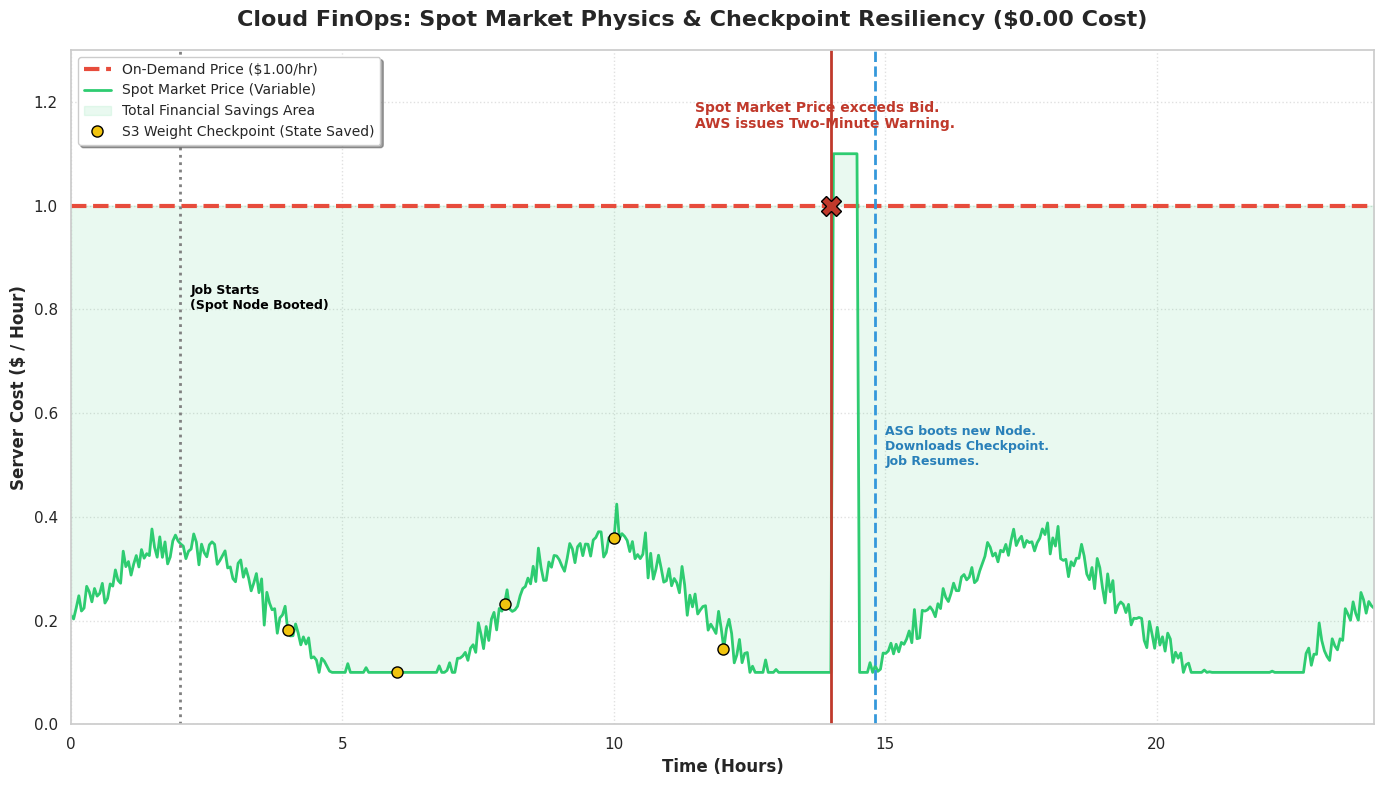

In [3]:
# Visualizing FinOps Spot Market Physics
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Cloud FinOps: Spot Market Physics & Checkpoint Resiliency ($0.00 Cost)", fontsize=16, fontweight='bold')

# 1. Generate Mathematical Market Data
np.random.seed(42)
hours = np.linspace(0, 24, 500)

# On-Demand is a flat horizontal line ($1.00/hr)
on_demand_price = np.full_like(hours, 1.00)

# Spot Price fluctuates based on simulated sine-wave demand + noise
spot_price = 0.20 + 0.15 * np.sin(hours * 0.8) + np.random.normal(0, 0.02, 500)
spot_price = np.clip(spot_price, 0.10, 0.90) # Cap bounds

# Inject a massive market spike (The Interruption Event)
spike_idx = np.where((hours > 14.0) & (hours < 14.5))[0]
spot_price[spike_idx] = 1.10 # Price exceeds On-Demand, triggering AWS to reclaim the instance!


# 2. Plot the Financial Baselines
ax.plot(hours, on_demand_price, color='#e74c3c', linewidth=3, linestyle='--', label="On-Demand Price ($1.00/hr)")
ax.plot(hours, spot_price, color='#2ecc71', linewidth=2, label="Spot Market Price (Variable)")
ax.fill_between(hours, spot_price, on_demand_price, color='#2ecc71', alpha=0.1, label="Total Financial Savings Area")


# 3. Plot the Compute Lifecycle & The Interruption Event
# Job starts at Hour 2
start_time = 2.0
ax.axvline(x=start_time, color='gray', linestyle=':', linewidth=2)
ax.text(start_time + 0.2, 0.8, "Job Starts\n(Spot Node Booted)", color='black', fontweight='bold', fontsize=9)

# The Interruption
interruption_time = 14.0
ax.plot(interruption_time, 1.0, marker='X', markersize=15, color='#c0392b', markeredgecolor='black', zorder=5)
ax.axvline(x=interruption_time, color='#c0392b', linestyle='-', linewidth=2)
ax.text(interruption_time - 2.5, 1.15, "Spot Market Price exceeds Bid.\nAWS issues Two-Minute Warning.", color='#c0392b', fontweight='bold', fontsize=10)

# Checkpointing frequency points (every 2 hours)
checkpoints = np.arange(4.0, interruption_time, 2.0)
for cp in checkpoints:
    ax.plot(cp, spot_price[int((cp/24)*500)], marker='o', markersize=8, color='#f1c40f', markeredgecolor='black', zorder=4)

ax.plot([], [], marker='o', markersize=8, color='#f1c40f', markeredgecolor='black', label="S3 Weight Checkpoint (State Saved)", linestyle="None")


# 4. Job Recovery
recovery_time = 14.8
ax.axvline(x=recovery_time, color='#3498db', linestyle='--', linewidth=2)
ax.text(recovery_time + 0.2, 0.5, "ASG boots new Node.\nDownloads Checkpoint.\nJob Resumes.", color='#2980b9', fontweight='bold', fontsize=9)


# 5. Styling and Formatting
ax.set_xlabel("Time (Hours)", fontweight='bold', fontsize=12)
ax.set_ylabel("Server Cost ($ / Hour)", fontweight='bold', fontsize=12)
ax.set_xlim(0, 24)
ax.set_ylim(0, 1.3)
ax.legend(loc="upper left", frameon=True, shadow=True, fontsize=10)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of Cloud FinOps and Spot Instances like **Flying Standby on a Commercial Airline**:

* **On-Demand Instances (Buying a First-Class Ticket):** You pay $1,000 for a guaranteed seat. The airline promises you will depart at 8:00 AM and arrive at 11:00 AM. It is mathematically safe, perfectly predictable, and incredibly expensive.
* **Spot Instances (Flying Standby):** You go to the airline and say: *"I will pay you $100 if you let me sit in an empty seat on the plane."* * The airline agrees, because making $100 is better than flying an empty seat.
* You get on the plane and start flying.
* Halfway through the flight, the plane lands in Chicago. A VIP customer runs to the gate willing to pay $1,000 for a seat.
* The airline walks up to you (The Two-Minute Warning) and says: *"Grab your bags, you have 120 seconds to get off this plane."*
* **If your architecture is Stateful:** You forgot your laptop on the plane (Corrupted data). You lose all your work and have to start the trip over from scratch.
* **If your architecture is Stateless (Checkpointing):** You grab your backpack, step off the plane into the terminal, wait 30 minutes for the next half-empty flight (Auto-Scaling Group), get on, and continue your trip.



By engineering checkpoint mechanisms and utilizing ASG Mixed Instance Policies, Data Engineers unlock 90% hardware discounts, allowing enterprises to train massive LLMs and process petabytes of data for pennies on the dollar.